In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1.0 - Pooling Cross Sections across Time: Simple Panel Data Methods

## 1.1 - Pooling Independent Cross Sections across Time (Pooled OLS)

###Example 1.2 -  Changes in the Return to Education and the Gender Wage Gap

>We can also interact a year dummy variable with key explanatory variables to see if the effect of that variable has changed over a certain time period. <br/><br/>
The next example examines how the return to education and the gender gap have changed from 1978 to 1985.

#### 📊 Dataset Overview: CPS78_85

The `CPS78_85` dataset is a pooled cross-sectional dataset combining data from the 1978 and 1985 U.S. **Current Population Surveys (CPS)**. It is commonly used in labor economics and econometrics courses, especially in applications involving wage determination and policy evaluation.<br/>

🔹 Source
Compiled by Professor Henry Farber from CPS microdata.

🔹 Observations
- Total: 1,084 individuals
  - 550 from 1978
  - 534 from 1985

🔹 Key Variables

| Variable   | Description |
|------------|-------------|
| `educ`     | Years of schooling |
| `south`    | = 1 if living in the South |
| `nonwhite` | = 1 if nonwhite |
| `female`   | = 1 if female |
| `married`  | = 1 if married |
| `exper`    | Potential experience (`age - educ - 6`) |
| `expersq`  | Square of experience |
| `union`    | = 1 if in a labor union |
| `lwage`    | Log of hourly wage |
| `age`      | Age in years |
| `year`     | Year of observation (1978 or 1985) |
| `y85`      | = 1 if year is 1985 |
| `y85fem`   | Interaction: female × y85 |
| `y85educ`  | Interaction: educ × y85 |
| `y85union` | Interaction: union × y85 |

🔹 Typical Uses
- Estimating returns to education
- Analyzing union wage premiums
- Examining the gender wage gap over time
- Comparing pooled vs. year-specific regression estimates

#### Data description

**A** log(wage) equation (where wage is hourly wage) pooled across the years 1978 (the base year) and 1985 is:
<br>
>$\log(\text{wage}) = \beta_0 + \delta_0 y85 + \beta_1 \text{educ} + \delta_1 y85 \text{educ} + \beta_2 \text{exper} + \beta_3 \text{exper}^2 + \beta_4 \text{union} + \beta_5 \text{female} + \delta_5 y85 \text{female} + u$
<br>
*   $\log(\text{wage})$, where wage is hourly wage, adjusted for inflation.
*   $\beta_0$ is the intercept for 1978.
*   $\beta_0+\delta_0$ is the intercept for 1985.
*   *y85* is a dummy variable equal to one if the observation comes from 1985 and zero if it comes from 1978.
*   $\beta_1$: The return to education in 1978.
*   *educ* is years of education.
*   *y85educ* is the interaction between *y85* dummy variable and *educ*.
*   $\delta_1$ measures how the return to another year of education has changed over the seven-year period.
*   $\beta_1+\delta_1$: The return to education in 1985.
*   $\delta_5$, coefficient for the interaction term between time-dummy and *female*, can tell us that nothing has happened to the gender (gap) differential over the seven-year period.
*   $\beta_5$ measures the log(wage) difference between women and men in 1978.
*   $\beta_5+\delta_5$ measures the log(wage) difference between women and men in 1985.
*   *union* is a dummy variable equal to one if the person belongs to a union, and zero otherwise.

#### Hypothesis Tests


1. Effect of Education Over Time


>**H₀:** δ₁ = 0 — Return to education has not changed wages over the seven-year period.  
**H₁:** δ₁ < 0 — Return to education has had a negative effect on wages over the seven-year period.

<br>

2. Gender Wage Gap Over Time

>**H₀:** δ₅ = 0 — The gender differential in wages has not changed over the seven-year period.  
**H₁:** δ₅ > 0 — The gender differential has decreased (i.e., the wage gap has narrowed).

#### Import the Dataset(s) and libraries

In [2]:
# import libraries
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np

# import data
chgs = pd.read_stata('/content/drive/MyDrive/Colab Notebooks/PM I/Data/CPS78_85.dta')

#### Explore the dataset

In [3]:
# Return the first 5 rows.
chgs.head()

,educ,south,nonwhite,female,married,exper,expersq,union,lwage,age,year,y85,y85fem,y85educ,y85union
0,12,0,0,0,0,8,64,0,1.2150,25,78,0,0,0,0
1,12,0,0,1,1,30,900,1,1.6094,47,78,0,0,0,0
2,6,0,0,0,1,38,1444,1,2.1401,49,78,0,0,0,0
3,12,0,0,0,1,19,361,1,2.0732,36,78,0,0,0,0
4,12,0,0,0,1,11,121,0,1.6490,28,78,0,0,0,0


In [4]:
len(chgs)

1084

In [5]:
chgs['year'].value_counts()

,count
year,
78,550
85,534


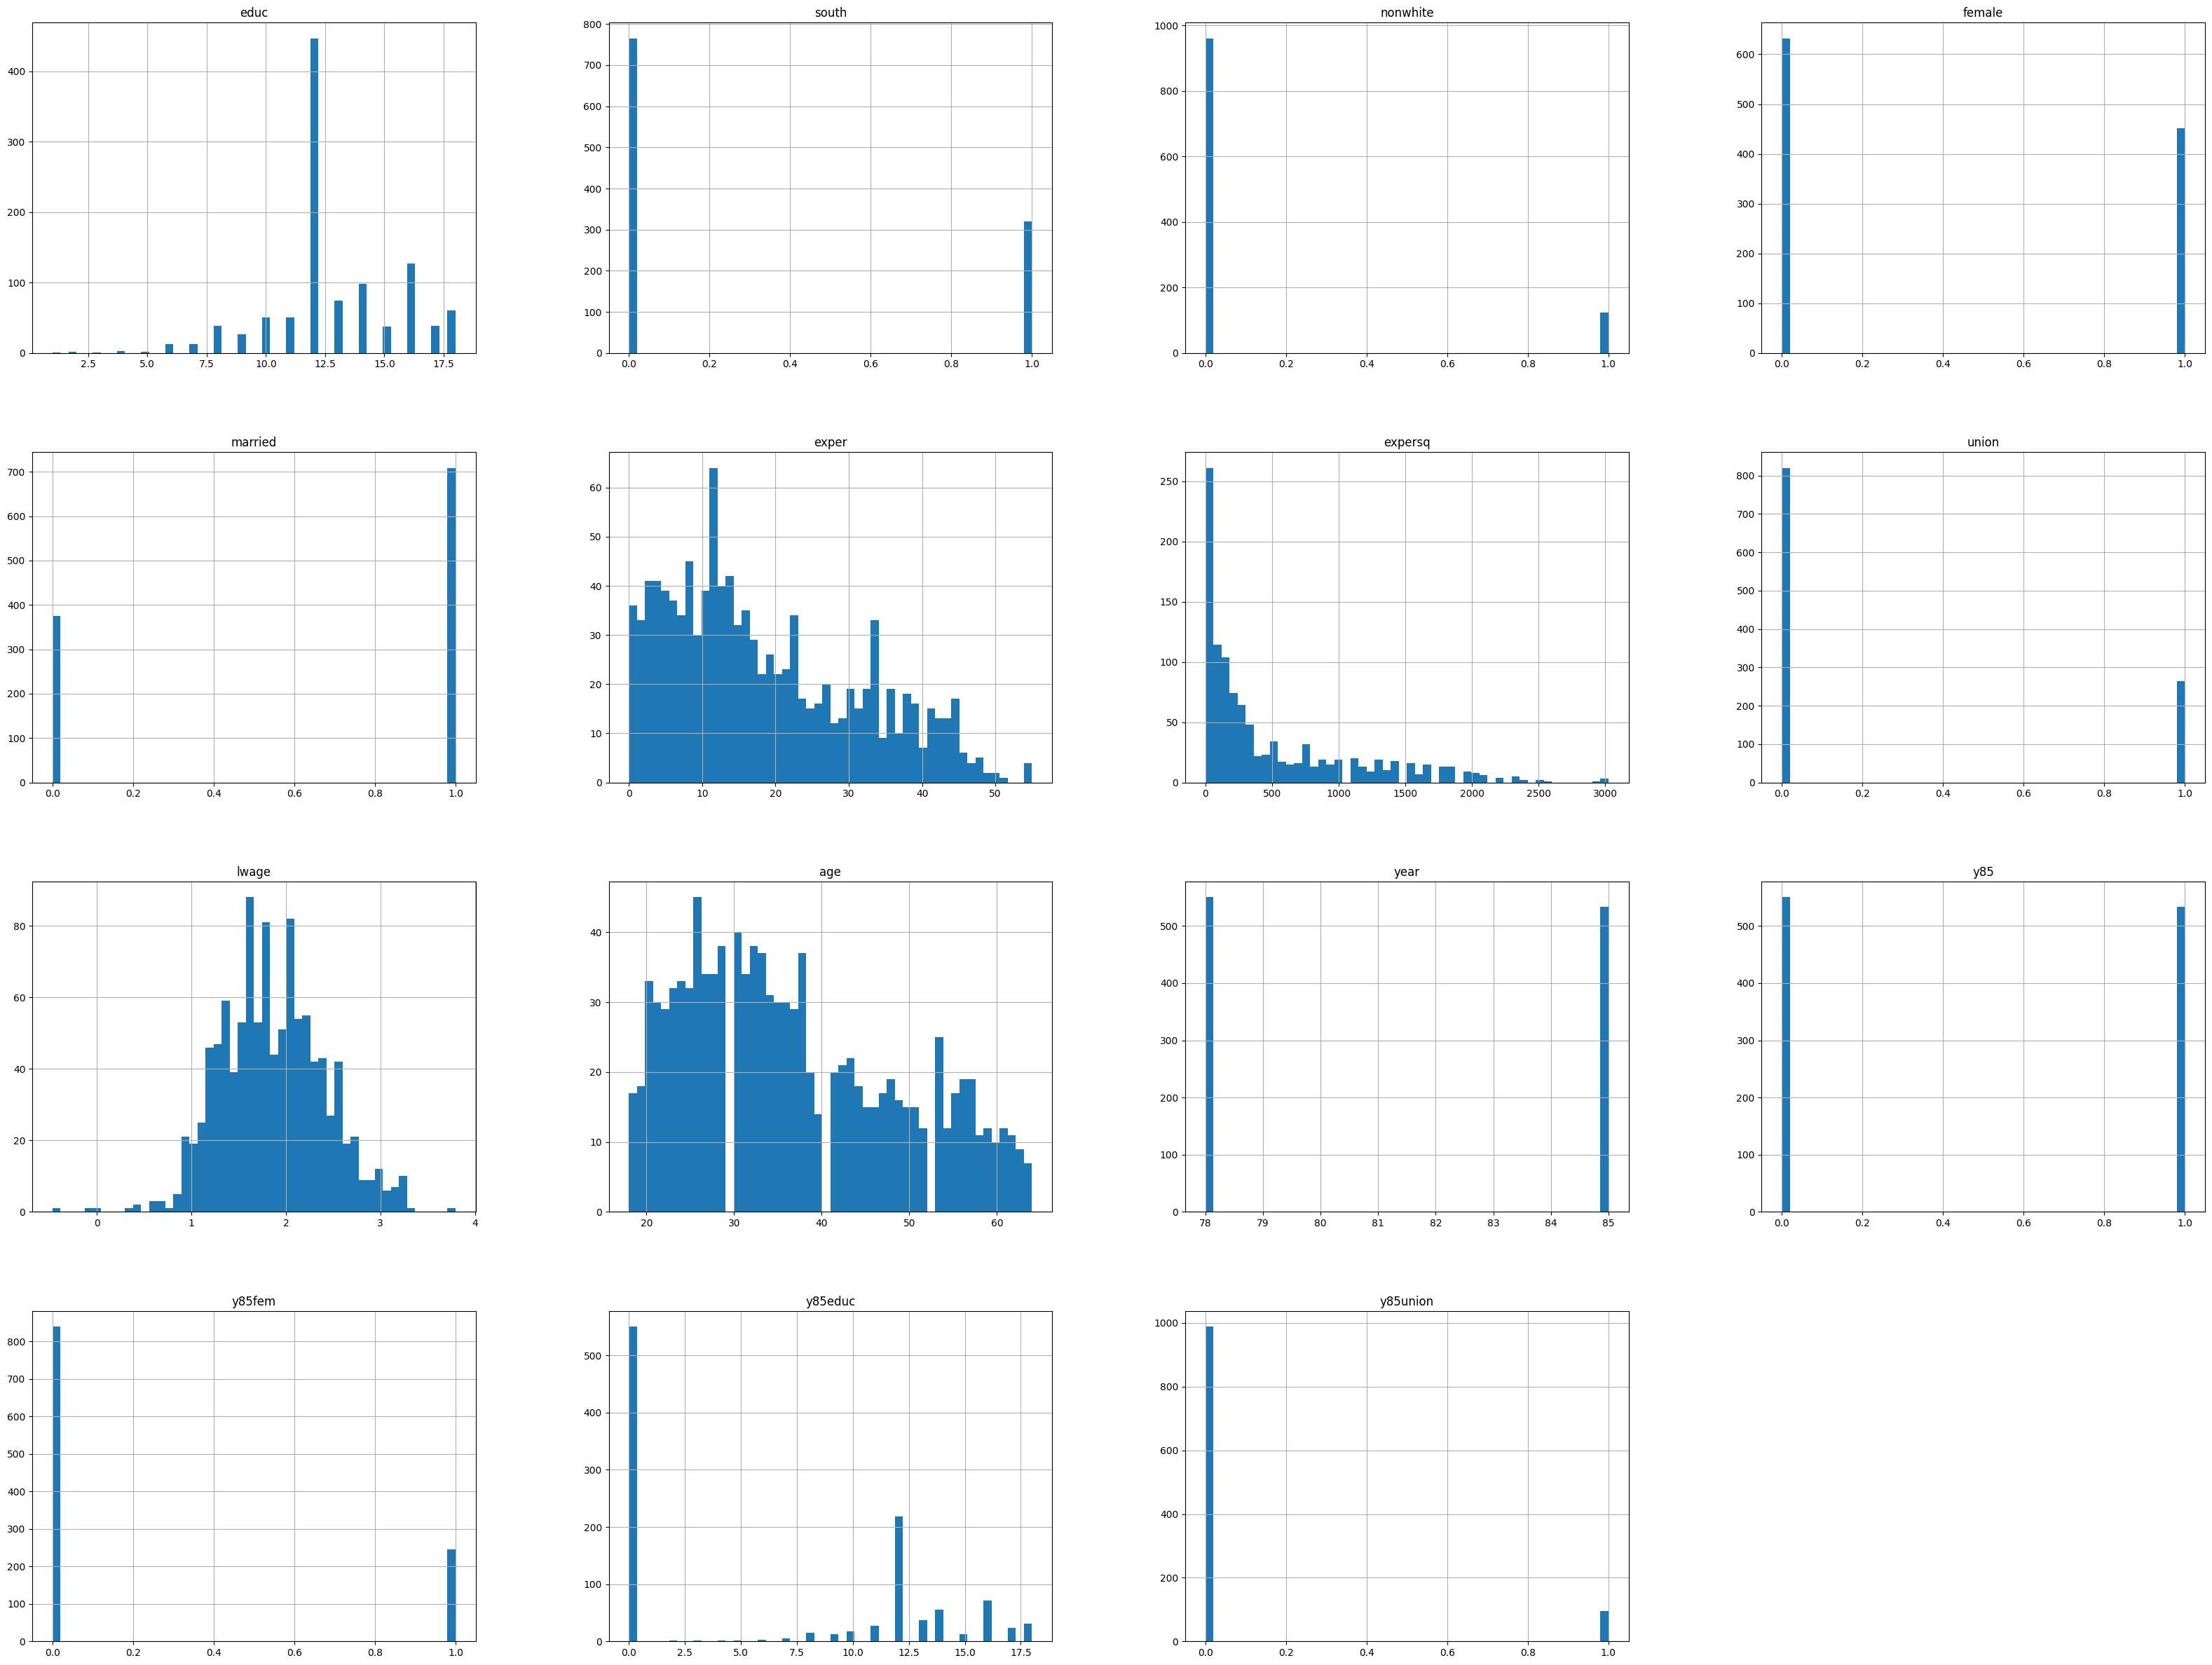

In [6]:
# Plot the distribution of the variables. Plots histograms for all numeric columns in one figure.
chgs.select_dtypes(include='number').hist(bins=50, figsize=(40, 30))
plt.savefig("chgs_attribute_histogram_plots")
plt.show()

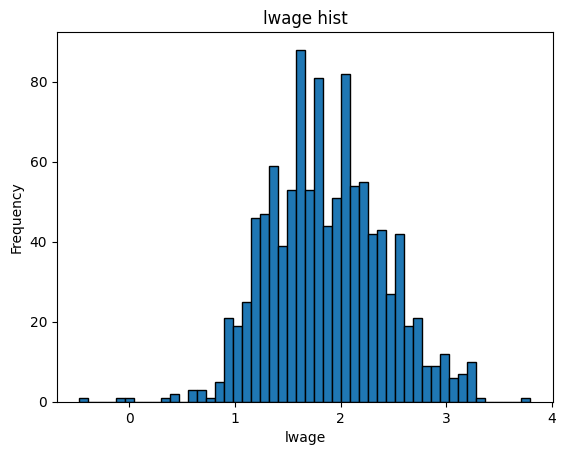

In [7]:
# Plot a histogram of lwage
plt.hist(chgs["lwage"], bins=50, edgecolor='black')
plt.title("lwage hist")
plt.xlabel("lwage")
plt.ylabel("Frequency")
plt.show()

In [8]:
# Quick overview of the structure of the DataFrame: Index range, Column names and data types, Non-null counts, Memory usage
chgs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1084 entries, 0 to 1083
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   educ      1084 non-null   int8   
 1   south     1084 non-null   int8   
 2   nonwhite  1084 non-null   int8   
 3   female    1084 non-null   int8   
 4   married   1084 non-null   int8   
 5   exper     1084 non-null   int8   
 6   expersq   1084 non-null   int16  
 7   union     1084 non-null   int8   
 8   lwage     1084 non-null   float32
 9   age       1084 non-null   int8   
 10  year      1084 non-null   int8   
 11  y85       1084 non-null   int8   
 12  y85fem    1084 non-null   int8   
 13  y85educ   1084 non-null   int8   
 14  y85union  1084 non-null   int8   
dtypes: float32(1), int16(1), int8(13)
memory usage: 20.2 KB


In [9]:
# chgs.columns returns a list-like object containing the names of all columns in the chgs DataFrame.
chgs.columns

Index(['educ', 'south', 'nonwhite', 'female', 'married', 'exper', 'expersq',
       'union', 'lwage', 'age', 'year', 'y85', 'y85fem', 'y85educ',
       'y85union'],
      dtype='object')

**Before we go into the linear regression model, let's briefly explain why we use "log(wage)" instead of unlogged wages.**

#### Why log-transform?

Real-world data like income, wages, or house prices are often **right-skewed** — most values are low or moderate, but a few are extremely high.

Taking the logarithm **compresses large values more than small ones**, pulling the high end of the distribution closer to the center.  

**Benefit:** This transformation makes the distribution more **symmetric and closer to normal**, which is a key assumption in many statistical models, including linear regression.

- The **first plot** is a histogram of unlogged wages (exponentiated from `log(wage)`). You will notice it is **right-skewed**.  
- The **second plot** shows the distribution of **logged wages**, which appears approximately **normally distributed**, making it more suitable for linear regression.


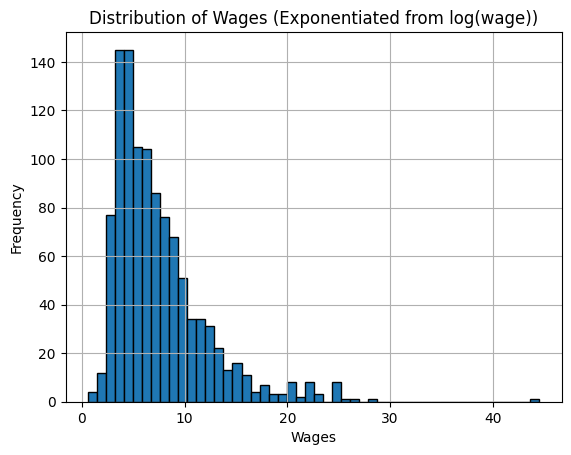

In [10]:
# Histogram of unlogged wages
chgs["lwage"].apply(np.exp).hist(bins=50, edgecolor="black")
plt.xlabel("Wages")
plt.ylabel("Frequency")
plt.title("Distribution of Wages (Exponentiated from log(wage))")
plt.show()

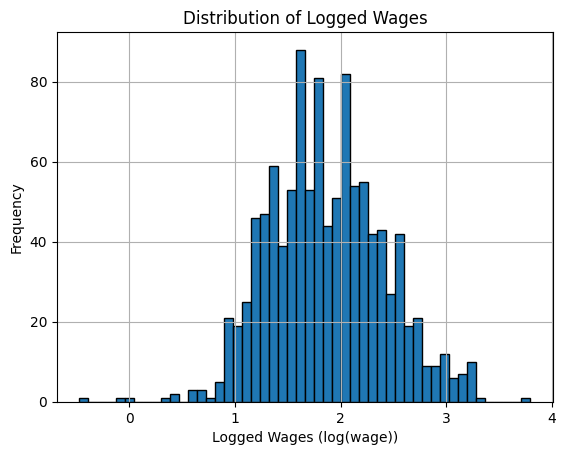

In [11]:
# Histogram of logged wages
chgs["lwage"].hist(bins=50, edgecolor="black")
plt.xlabel("Logged Wages (log(wage))")
plt.ylabel("Frequency")
plt.title("Distribution of Logged Wages")
plt.show()

#### Apply a linear regression model

$\log(\text{wage}) = \beta_0 + \delta_0 y85 + \beta_1 \text{educ} + \delta_1 y85 \text{educ} + \beta_2 \text{exper} + \beta_3 \text{exper}^2 + \beta_4 \text{union} + \beta_5 \text{female} + \delta_5 y85 \text{female} + u$

In [12]:
import statsmodels.formula.api as smf
# Fit the model
fit = smf.ols('lwage ~ y85 + educ + y85*educ + exper + expersq + union + female + y85*female', data=chgs ).fit()

# Show the results
print(fit.summary())
print(f"\nNote: R-squared: {fit.rsquared:.4f}")
print(f"\nNote: This linear regression model can explain {fit.rsquared * 100:.2f}% of variability of the dependent variable")

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     99.80
Date:                Thu, 24 Jul 2025   Prob (F-statistic):          4.46e-124
Time:                        20:03:28   Log-Likelihood:                -574.24
No. Observations:                1084   AIC:                             1166.
Df Residuals:                    1075   BIC:                             1211.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4589      0.093      4.911      0.0

####**Findings**

#####**Hypothesis Test #1**: Effect of Education Over Time

>**Hypotheses**  
H₀: δ₁ = 0 — Return to education has not changed wages over the seven-year period.  
H₁: δ₁ < 0 — Return to education has had a negative effect on wages over the seven-year period.

>**Results**  
- Estimated δ₁ (i.e. y85:educ) = 0.0185  
- |p-value| = 0.049


>**Conclusion**  
- p-value is just below 0.05 ⇒ reject H₀ at the 5% level.  
- However, δ₁ > 0 — effect is **positive**, not negative.  
- So, while the change is statistically significant, it contradicts H₁.  

>**Interpretation**  
- Return to education may have **increased**, not decreased, over time.

#####**Hypothesis Test #2**: Gender Wage Gap Over Time

>**Hypotheses**  
H₀: δ₅ = 0 — The gender differential in wages has not changed over the seven-year period.  
H₁: δ₅ > 0 — The gender differential has decreased (i.e., the wage gap has narrowed).

>**Results**  
- Estimated δ₅ (i.e., *y85:female*) = **0.0851**  
- *t*-statistic = **1.653**  
- *p*-value (one-sided, right-tailed) = **0.049**  
    - Original two-tailed *p*-value: 0.098  
    - One-tailed adjustment (for H₁: δ₅ > 0): **0.098 ÷ 2 = 0.049**

>**Conclusion**  
- Since the one-sided *p*-value = 0.049 < 0.05, we **reject H₀** at the 5% level.  
- This supports the hypothesis that the gender wage gap has **narrowed** over time.

>**Interpretation**  
- In 1978, women earned approximately **31.7% less** than men:  
  - β₅ = -0.3167
- In 1985, the gap reduced to about **23.2%**:  
  - β₅ + δ₅ = -0.3167 + 0.0851 = -0.2316
- This suggests an **8.5 percentage point improvement** in the gender wage gap over the period, all else equal.